In [1]:
import os
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer

In [2]:
print(os.getcwd())
os.chdir("../")
os.getcwd()

c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\notebooks


'c:\\Users\\leoco\\Documents\\cours\\M2_MOSEF\\ML_theory\\land_value_prediction'

In [3]:
from src.land_value_prediction.feature_selection import (compute_shap_results, 
                                                         compute_shap_summary, 
                                                         plot_strong_correlations)

c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_train = pd.read_parquet(r"data\processed\train_test_out_sample_cleaned\idf_vf_train_cleaned.parquet")

In [5]:
cols_to_remove = ['prix_m2', 'ecart_prix_median_pct', 'is_maison', 'nord_paris', 'est_paris', "code_departement"]
df_code_departement = df_train[['code_departement']].copy()

X = df_train.drop(columns=cols_to_remove)
y = df_train['prix_m2']

print(f"Dataset: {X.shape[0]:,} échantillons, {X.shape[1]} features")
print(f"Target (prix_m2): min={y.min():.0f}, max={y.max():.0f}, médiane={y.median():.0f}")

Dataset: 469,174 échantillons, 102 features
Target (prix_m2): min=1500, max=15000, médiane=4769


In [6]:
# Créer 10 bins pour stratification
n_bins = 10
binner = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
y_binned = binner.fit_transform(y.values.reshape(-1, 1)).ravel().astype(int)

# Vérifier la distribution
print(f"Target divisée en {n_bins} bins (quantiles)")
bin_counts = pd.Series(y_binned).value_counts().sort_index()
print("Distribution des bins:")
for bin_idx, count in bin_counts.items():
    print(f"   Bin {int(bin_idx)}: {count:>6} échantillons ({count/len(y)*100:>5.1f}%)")

Target divisée en 10 bins (quantiles)
Distribution des bins:
   Bin 0:  46277 échantillons (  9.9%)
   Bin 1:  47035 échantillons ( 10.0%)
   Bin 2:  47028 échantillons ( 10.0%)
   Bin 3:  46734 échantillons ( 10.0%)
   Bin 4:  46181 échantillons (  9.8%)
   Bin 5:  47579 échantillons ( 10.1%)
   Bin 6:  47383 échantillons ( 10.1%)
   Bin 7:  46915 échantillons ( 10.0%)
   Bin 8:  46945 échantillons ( 10.0%)
   Bin 9:  47097 échantillons ( 10.0%)


c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [7]:
shap_results = compute_shap_results(X, y, y_binned, binner=binner, n_bins=n_bins, n_folds=5)

 FOLD 1/5
   Train: 375339 échantillons
   Val:   93835 échantillons
   Target train: min=1500, Q25=3315, med=4769, Q75=8001, max=15000
   MAE train: 1002.51
   MAE val:   1010.01
 FOLD 2/5
   Train: 375339 échantillons
   Val:   93835 échantillons
   Target train: min=1500, Q25=3315, med=4769, Q75=8009, max=15000
   MAE train: 1002.18
   MAE val:   1007.92
 FOLD 3/5
   Train: 375339 échantillons
   Val:   93835 échantillons
   Target train: min=1500, Q25=3314, med=4769, Q75=8011, max=15000
   MAE train: 1003.52
   MAE val:   1005.07
 FOLD 4/5
   Train: 375339 échantillons
   Val:   93835 échantillons
   Target train: min=1500, Q25=3313, med=4769, Q75=8010, max=15000
   MAE train: 1001.67
   MAE val:   1008.62
 FOLD 5/5
   Train: 375340 échantillons
   Val:   93834 échantillons
   Target train: min=1500, Q25=3315, med=4769, Q75=8006, max=15000
   MAE train: 1001.71
   MAE val:   1015.46


Pas d'overfit, la sélection est robuste. Et ça donne également un benchmark avec une MAE d'environ 1000. 

In [8]:
results_df = compute_shap_summary(shap_results, X)
results_df

,feature,shap_mean,shap_norm
3,prix_m2_median_maisons_voisines,1323.772860,100.000000
92,ratio_terrain_bati,352.029200,26.589100
100,surface_x_type,293.596532,22.174772
25,commune_education_score_2013_commune,219.441207,16.572668
90,densite_rel_2000m,218.929507,16.534011
...,...,...,...
48,nb_commerce_500m,0.268599,0.015155
62,nb_transport_autre_500m,0.192779,0.009427
52,nb_sante_500m,0.176847,0.008223
45,IPC_base_2015_lag12m,0.176611,0.008205


On ne garde que les variables pour lesquelles la valeur de shapley est supérieure à 1% de la valeur de Shapley maximum. 

In [9]:
selected_features = results_df[results_df["shap_norm"] > 1]["feature"].tolist()
print(f"On ne garde que {len(selected_features)} features avec un SHAP normalisé > 1")
print(f"Ce sont les features suivantes: {selected_features}")

On ne garde que 30 features avec un SHAP normalisé > 1
Ce sont les features suivantes: ['prix_m2_median_maisons_voisines', 'ratio_terrain_bati', 'surface_x_type', 'commune_education_score_2013_commune', 'densite_rel_2000m', 'is_appartement', 'nombre_lots', 'nb_transport_autre_2000m', 'commune_part_commerce_tourisme', 'commune_densite_residences_principales_2020', 'distance_paris', 'nombre_pieces_principales', 'commune_revenu_median_2020', 'commune_etablissements_1_salarie_2021', 'surface_terrain', 'nb_jours_depuis_janvier_2021', 'surface_par_piece', 'densite_lots', 'commune_ratio_residences_secondaires_population', 'Taux_moyen_credit_immo_lag3t', 'nb_loisirs_2000m', 'Taux_moyen_credit_immo_lag1t', 'commune_idh2_2013_commune', 'nb_total_2000m', 'prix_median_x_distance', 'commune_taux_proprietaires', 'dist_transport_lourd', 'Evolution_PIB_volume_en_%_base2020_lag4t', 'nb_services_2000m', 'commune_taux_residences_secondaires']


In [10]:
df_train_with_selected_features = df_train[selected_features + ['prix_m2']]
df_train_with_selected_features

,prix_m2_median_maisons_voisines,ratio_terrain_bati,surface_x_type,commune_education_score_2013_commune,densite_rel_2000m,is_appartement,nombre_lots,nb_transport_autre_2000m,commune_part_commerce_tourisme,commune_densite_residences_principales_2020,...,Taux_moyen_credit_immo_lag1t,commune_idh2_2013_commune,nb_total_2000m,prix_median_x_distance,commune_taux_proprietaires,dist_transport_lourd,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m,commune_taux_residences_secondaires,prix_m2
0,11000.000000,0.000000,96,0.824937,2.005092,1,1,29,0.852084,15346.884766,...,0.0120,0.662507,1074,251.875809,0.370956,144.457687,-5.068832,14,0.095681,9437.500000
1,5948.511230,0.000000,90,0.471073,0.919889,1,2,0,0.695597,4164.813965,...,0.0113,0.469822,734,400.319183,0.243751,600.407043,-12.214629,8,0.016327,4666.666504
2,12951.613281,0.000000,102,0.998930,2.168607,1,2,43,0.862807,12465.445312,...,0.0140,0.854362,1186,159.726929,0.345093,152.974091,2.991206,18,0.145795,12549.019531
3,12958.437500,0.000000,240,0.960340,2.177448,1,1,49,0.894205,10157.753906,...,0.0120,0.786219,1128,130.780746,0.316352,118.246140,-5.068832,17,0.191499,12750.000000
4,3145.161377,2.227273,88,0.455148,-1.035969,0,0,1,0.657143,461.768066,...,0.0178,0.506256,141,1062.413452,0.557275,1995.224365,0.559991,7,0.007369,3693.181885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469169,2194.827637,0.000000,140,0.558072,-1.026805,1,2,1,0.714286,1754.606445,...,0.0140,0.571913,144,1287.721924,0.523755,2903.486328,2.991206,1,0.032652,1571.428589
469170,3378.333252,4.601942,103,0.443735,-0.967486,0,0,1,0.741100,208.464325,...,0.0106,0.506048,136,1504.184082,0.465197,597.018799,15.361810,0,0.005456,3249.514648
469171,1954.318970,7.727273,110,0.377666,-1.427457,0,0,0,0.500000,26.528963,...,0.0112,0.492055,17,1617.224731,0.666281,13838.716797,1.215887,2,0.092558,1954.545410
469172,3367.519775,2.870588,85,0.355047,-0.998366,0,0,1,0.744986,558.810059,...,0.0113,0.461330,133,1725.429565,0.475808,1396.384399,-12.214629,5,0.008542,3917.646973


On doit maintenant procéder à une nouvelle analyse des corrélations présentes dans le dataframe :

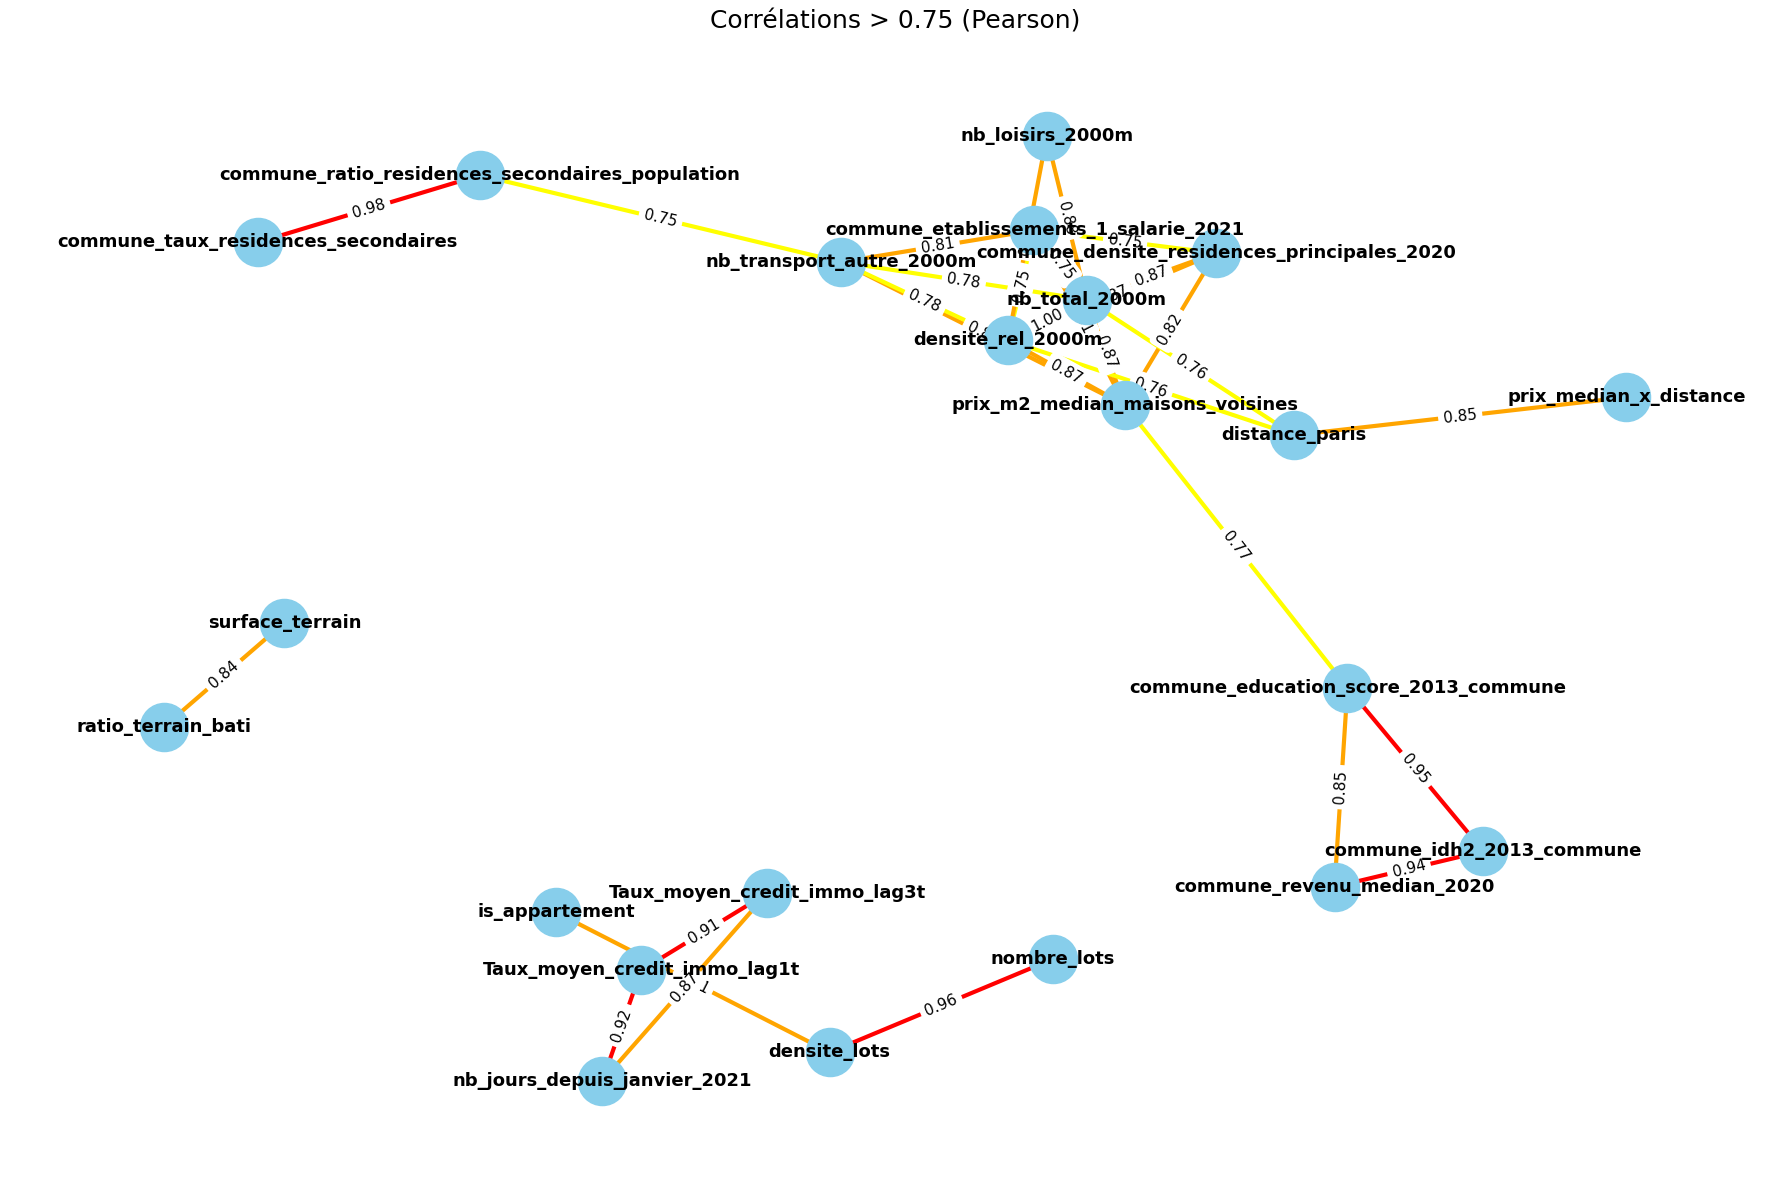

In [11]:
plot_strong_correlations(df_train_with_selected_features.drop(columns="prix_m2"), threshold=0.75)

A partir de cette annalyse on va enlever quelques variables, on garde à chaque fois la variable qui a la plus grande valeur de shapley:

In [12]:
correlated_features_to_drop = ["surface_terrain",
                               "densite_lots", 
                               "Taux_moyen_credit_immo_lag3t", 
                               "nb_jours_depuis_janvier_2021", # cette variable ne fait pas sens
                               "nb_education_2000m", 
                               "commune_idh2_2013_commune", 
                               "prix_median_x_distance",
                               "commune_taux_residences_secondaires",
                               "nb_total_2000m", 
                               "commune_densite_pop"
                               ]

df_train_with_selected_features = df_train_with_selected_features.drop(columns=correlated_features_to_drop, errors='ignore')
df_train_with_selected_features

,prix_m2_median_maisons_voisines,ratio_terrain_bati,surface_x_type,commune_education_score_2013_commune,densite_rel_2000m,is_appartement,nombre_lots,nb_transport_autre_2000m,commune_part_commerce_tourisme,commune_densite_residences_principales_2020,...,commune_etablissements_1_salarie_2021,surface_par_piece,commune_ratio_residences_secondaires_population,nb_loisirs_2000m,Taux_moyen_credit_immo_lag1t,commune_taux_proprietaires,dist_transport_lourd,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m,prix_m2
0,11000.000000,0.000000,96,0.824937,2.005092,1,1,29,0.852084,15346.884766,...,6757,16.0,0.093602,311,0.0120,0.370956,144.457687,-5.068832,14,9437.500000
1,5948.511230,0.000000,90,0.471073,0.919889,1,2,0,0.695597,4164.813965,...,550,15.0,0.010882,332,0.0113,0.243751,600.407043,-12.214629,8,4666.666504
2,12951.613281,0.000000,102,0.998930,2.168607,1,2,43,0.862807,12465.445312,...,3526,25.5,0.146887,270,0.0140,0.345093,152.974091,2.991206,18,12549.019531
3,12958.437500,0.000000,240,0.960340,2.177448,1,1,49,0.894205,10157.753906,...,2811,40.0,0.211263,252,0.0120,0.316352,118.246140,-5.068832,17,12750.000000
4,3145.161377,2.227273,88,0.455148,-1.035969,0,0,1,0.657143,461.768066,...,315,17.6,0.004247,41,0.0178,0.557275,1995.224365,0.559991,7,3693.181885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469169,2194.827637,0.000000,140,0.558072,-1.026805,1,2,1,0.714286,1754.606445,...,238,17.5,0.030661,53,0.0140,0.523755,2903.486328,2.991206,1,1571.428589
469170,3378.333252,4.601942,103,0.443735,-0.967486,0,0,1,0.741100,208.464325,...,414,20.6,0.003642,33,0.0106,0.465197,597.018799,15.361810,0,3249.514648
469171,1954.318970,7.727273,110,0.377666,-1.427457,0,0,0,0.500000,26.528963,...,25,27.5,0.083745,3,0.0112,0.666281,13838.716797,1.215887,2,1954.545410
469172,3367.519775,2.870588,85,0.355047,-0.998366,0,0,1,0.744986,558.810059,...,245,17.0,0.005702,51,0.0113,0.475808,1396.384399,-12.214629,5,3917.646973


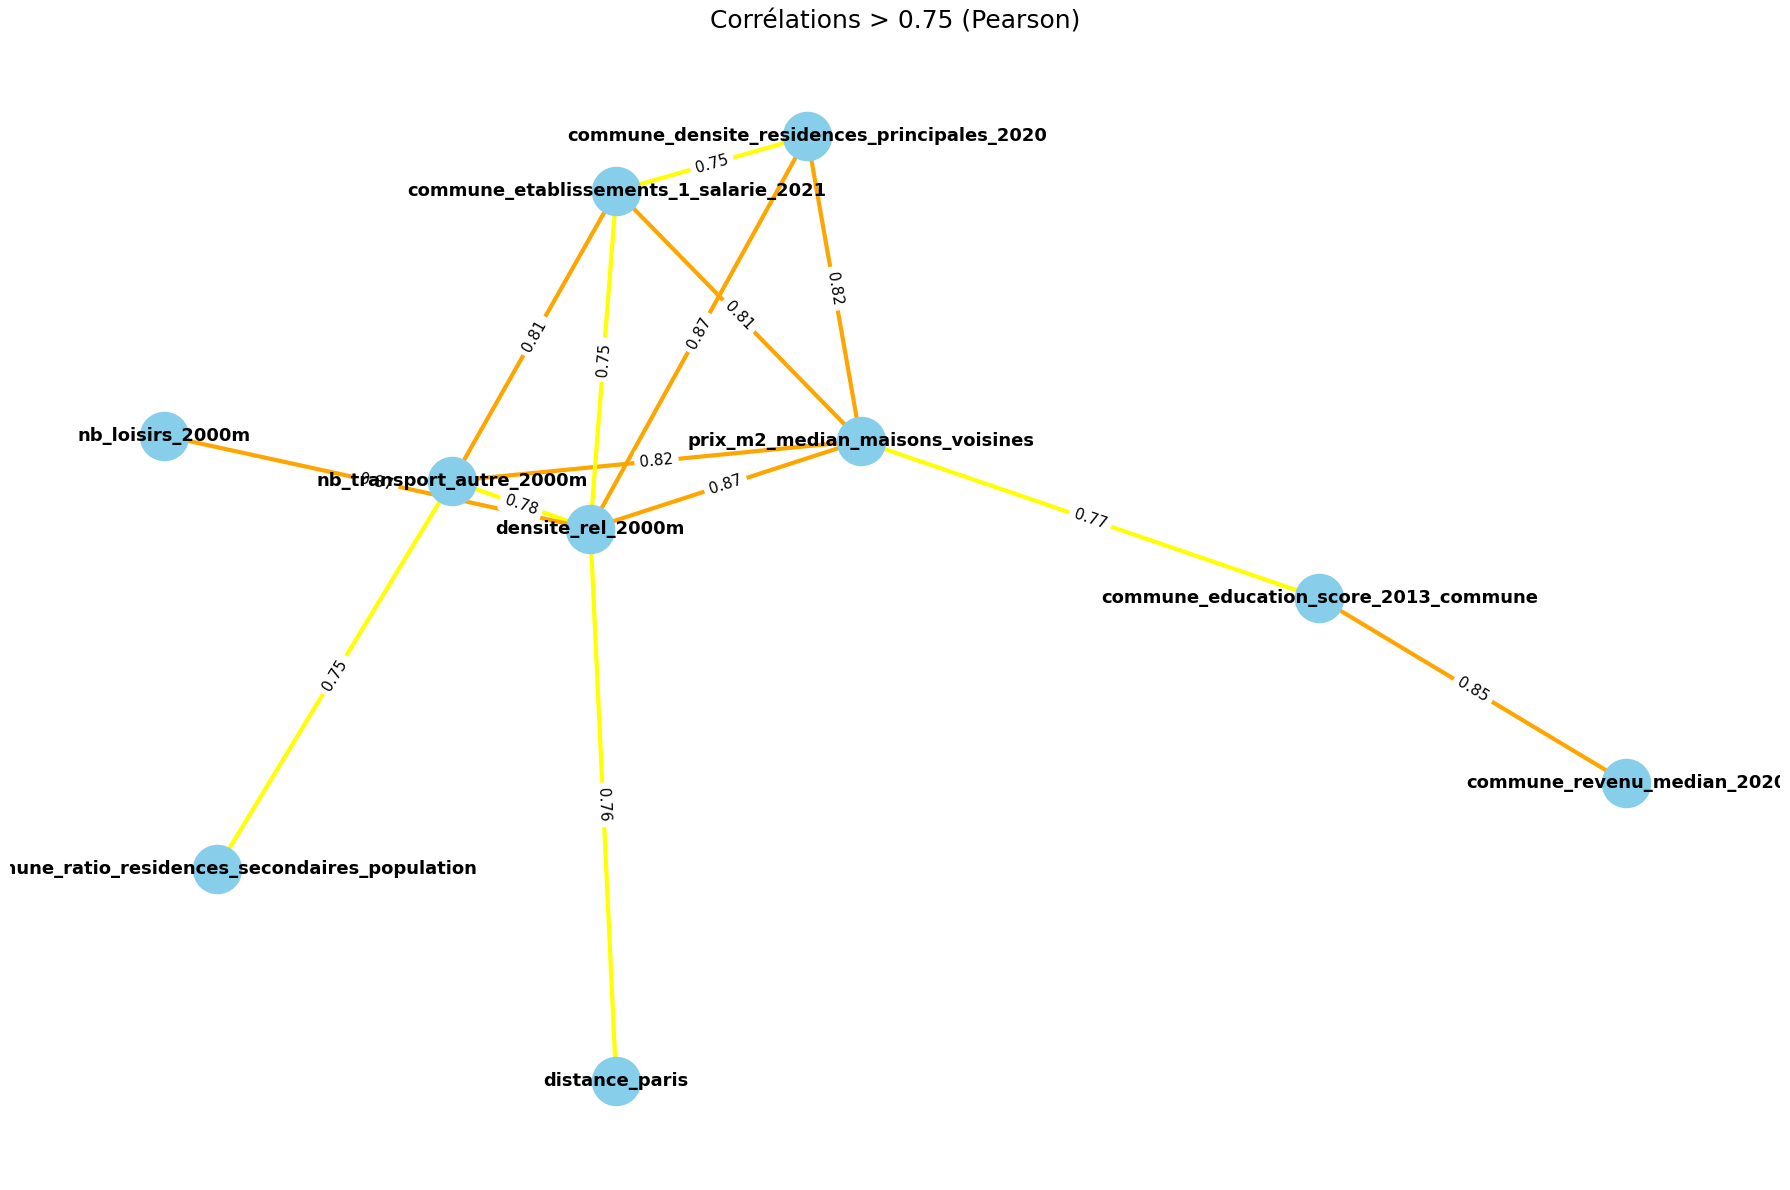

In [13]:
plot_strong_correlations(df_train_with_selected_features.drop(columns="prix_m2"), threshold=0.75)

Pour des modèles d'arbre ce n'est pas très grave pour la performance du modèle d'avoir des corrélations. Donc pour l'instant on garde le dataframe tel quel. Pour mieux comprendre les drivers du prix au mètre carré il faudra enlever le prix médian du metre carré des maisons voisines. 

On va rajouter le code departement :

In [14]:
df_train_with_selected_features = pd.concat([df_train_with_selected_features, df_code_departement], axis=1)
df_train_with_selected_features

,prix_m2_median_maisons_voisines,ratio_terrain_bati,surface_x_type,commune_education_score_2013_commune,densite_rel_2000m,is_appartement,nombre_lots,nb_transport_autre_2000m,commune_part_commerce_tourisme,commune_densite_residences_principales_2020,...,surface_par_piece,commune_ratio_residences_secondaires_population,nb_loisirs_2000m,Taux_moyen_credit_immo_lag1t,commune_taux_proprietaires,dist_transport_lourd,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m,prix_m2,code_departement
0,11000.000000,0.000000,96,0.824937,2.005092,1,1,29,0.852084,15346.884766,...,16.0,0.093602,311,0.0120,0.370956,144.457687,-5.068832,14,9437.500000,75
1,5948.511230,0.000000,90,0.471073,0.919889,1,2,0,0.695597,4164.813965,...,15.0,0.010882,332,0.0113,0.243751,600.407043,-12.214629,8,4666.666504,92
2,12951.613281,0.000000,102,0.998930,2.168607,1,2,43,0.862807,12465.445312,...,25.5,0.146887,270,0.0140,0.345093,152.974091,2.991206,18,12549.019531,75
3,12958.437500,0.000000,240,0.960340,2.177448,1,1,49,0.894205,10157.753906,...,40.0,0.211263,252,0.0120,0.316352,118.246140,-5.068832,17,12750.000000,75
4,3145.161377,2.227273,88,0.455148,-1.035969,0,0,1,0.657143,461.768066,...,17.6,0.004247,41,0.0178,0.557275,1995.224365,0.559991,7,3693.181885,77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469169,2194.827637,0.000000,140,0.558072,-1.026805,1,2,1,0.714286,1754.606445,...,17.5,0.030661,53,0.0140,0.523755,2903.486328,2.991206,1,1571.428589,77
469170,3378.333252,4.601942,103,0.443735,-0.967486,0,0,1,0.741100,208.464325,...,20.6,0.003642,33,0.0106,0.465197,597.018799,15.361810,0,3249.514648,78
469171,1954.318970,7.727273,110,0.377666,-1.427457,0,0,0,0.500000,26.528963,...,27.5,0.083745,3,0.0112,0.666281,13838.716797,1.215887,2,1954.545410,77
469172,3367.519775,2.870588,85,0.355047,-0.998366,0,0,1,0.744986,558.810059,...,17.0,0.005702,51,0.0113,0.475808,1396.384399,-12.214629,5,3917.646973,78


Appliquer la selection à l'échantillon test et OOT :

In [15]:
test_df = pd.read_parquet(r"data/processed/train_test_out_sample_cleaned/idf_vf_test_cleaned.parquet")
test_df = test_df[selected_features + ["prix_m2", "code_departement"]]
test_df = test_df.drop(columns=correlated_features_to_drop, errors='ignore')
test_df

,prix_m2_median_maisons_voisines,ratio_terrain_bati,surface_x_type,commune_education_score_2013_commune,densite_rel_2000m,is_appartement,nombre_lots,nb_transport_autre_2000m,commune_part_commerce_tourisme,commune_densite_residences_principales_2020,...,surface_par_piece,commune_ratio_residences_secondaires_population,nb_loisirs_2000m,Taux_moyen_credit_immo_lag1t,commune_taux_proprietaires,dist_transport_lourd,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m,prix_m2,code_departement
0,2967.117188,2.732240,183,0.583164,-1.473657,0,0,0,0.666667,39.789074,...,22.875000,0.027155,17,0.0373,0.940529,6243.615723,0.193834,1,3180.327881,78
1,3666.666748,3.853801,171,0.242647,0.128697,0,0,1,0.623197,2847.708984,...,19.000000,0.003927,151,0.0284,0.265317,433.623505,0.440900,12,2748.538086,93
2,3090.909180,1.556000,250,0.505031,-0.715705,0,0,3,0.713647,1505.883423,...,41.666668,0.006420,126,0.0359,0.619347,665.828735,0.451942,3,2000.000000,95
3,9946.428711,0.000000,106,0.727544,1.365996,1,2,15,0.829141,17184.078125,...,17.666666,0.057274,304,0.0377,0.326103,201.322708,0.385596,10,8867.924805,75
4,8171.543945,0.000000,49,0.835437,0.538358,0,1,2,0.834500,7529.934082,...,16.333334,0.054721,208,0.0106,0.422396,456.389435,15.361810,8,4795.918457,92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117289,7005.292969,0.000000,60,0.832653,1.255020,1,2,4,0.837838,9475.886719,...,30.000000,0.081091,350,0.0178,0.428526,367.999481,0.559991,14,8234.333008,92
117290,10275.361328,0.000000,88,0.824937,1.613592,1,2,28,0.852084,15346.884766,...,22.000000,0.093602,311,0.0222,0.370956,166.942993,-0.095774,12,7613.636230,75
117291,7116.091797,0.000000,68,0.508493,0.094701,1,1,1,0.715007,5485.638672,...,17.000000,0.012786,223,0.0377,0.357765,656.240356,0.385596,6,5617.646973,93
117292,5000.000000,6.304348,46,0.687261,-0.691548,0,0,0,0.661499,1163.347534,...,15.333333,0.024967,108,0.0373,0.674103,485.073700,0.193834,6,13469.782227,78


In [16]:
oos_df = pd.read_parquet(r"data/processed/train_test_out_sample_cleaned/idf_vf_out_of_sample_cleaned.parquet")
oos_df = oos_df[selected_features + ["prix_m2", "code_departement"]]
oos_df = oos_df.drop(columns=correlated_features_to_drop, errors='ignore')
oos_df

,prix_m2_median_maisons_voisines,ratio_terrain_bati,surface_x_type,commune_education_score_2013_commune,densite_rel_2000m,is_appartement,nombre_lots,nb_transport_autre_2000m,commune_part_commerce_tourisme,commune_densite_residences_principales_2020,...,surface_par_piece,commune_ratio_residences_secondaires_population,nb_loisirs_2000m,Taux_moyen_credit_immo_lag1t,commune_taux_proprietaires,dist_transport_lourd,Evolution_PIB_volume_en_%_base2020_lag4t,nb_services_2000m,prix_m2,code_departement
0,4005.208252,0.000000,144,0.400966,0.003226,1,1,2,0.635346,3260.181641,...,24.000000,0.010006,255,0.0338,0.372387,134.432617,0.144057,8,3097.222168,94
1,3682.135010,0.000000,156,0.610739,-0.832668,1,2,0,0.823000,1154.910645,...,19.500000,0.036247,72,0.0338,0.409828,135.523117,0.144057,7,3551.281982,78
2,5482.353027,0.000000,30,0.889821,-0.042039,1,1,0,0.810565,2509.519531,...,15.000000,0.026782,174,0.0338,0.477340,145.372406,0.144057,2,8000.000000,92
3,8277.418945,0.000000,124,0.835437,0.742554,1,1,5,0.834500,7529.934082,...,20.666666,0.054721,314,0.0338,0.422396,622.195190,0.144057,6,7658.467773,92
4,2683.333252,0.000000,204,0.389963,-0.651608,1,1,1,0.659074,1908.057251,...,20.400000,0.004541,127,0.0338,0.391079,1174.676025,0.144057,8,1980.392212,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47763,3621.912109,3.026316,76,0.523603,-1.089169,0,0,0,0.633484,611.100769,...,19.000000,0.005232,94,0.0316,0.649097,2226.469971,0.191300,2,3723.684326,77
47764,3579.545410,0.000000,184,0.473365,-0.129552,1,1,0,0.619617,1849.035278,...,23.000000,0.009441,213,0.0316,0.650443,1345.507935,0.191300,6,1569.934814,91
47765,4420.212891,0.000000,120,0.682606,0.208427,1,1,2,0.755556,1658.850098,...,20.000000,0.044261,326,0.0316,0.453915,1653.855713,0.191300,3,5000.000000,78
47766,4289.473633,3.674797,123,0.639937,-1.055975,0,0,1,0.637681,410.480469,...,20.500000,0.004543,64,0.0316,0.730947,1396.173706,0.191300,2,3869.918701,78


Export de la base :

In [17]:
df_train_with_selected_features.to_parquet(r"data/processed/selected_features/idf_vf_train_selected_features.parquet", index=False)
test_df.to_parquet(r"data/processed/selected_features/idf_vf_test_selected_features.parquet", index=False)
oos_df.to_parquet(r"data/processed/selected_features/idf_vf_out_of_sample_selected_features.parquet", index=False)